In [39]:
import torch.nn as nn
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
import numpy as np
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [40]:
class CNNBlock(nn.Module):
  def __init__(self,in_channels,out_channels,kernel_size,padding,stride,pool = 'max', bias=True,pool_stride=1):
    super().__init__()
    self.conv = nn.Sequential(
        nn.Conv2d(in_channels,out_channels,kernel_size,stride,padding,bias=bias),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,stride = pool_stride) if pool == 'max' else nn.AvgPool2d(kernel_size = 2,stride=pool_stride)
    )
  def forward(self,x):
    return self.conv(x)

In [41]:
class Assignment2(nn.Module):
  # here part2 is the 2nd part of this assignment
  def __init__(self, part2=False):
    super().__init__()
    self.conv1 = CNNBlock(in_channels=1,out_channels=16,kernel_size=7,padding=3,stride=1,pool_stride = 2)
    self.conv2 = CNNBlock(in_channels=16,out_channels=8,kernel_size=5,padding=2,stride=1,pool_stride=2)
    self.conv3 = CNNBlock(in_channels=8,out_channels=4,kernel_size=3,padding=1,stride=2,pool='avg',pool_stride=2)
    self.output = nn.Linear(16, 4 if part2 else 10)
  def forward(self,x):
    x = self.conv1(x)
    # print('After conv 1 ',x.shape)
    x = self.conv2(x)
    # print('After conv 2 ',x.shape)
    x = self.conv3(x)
    # print('After conv 3 ',x.shape)
    x = x.flatten(1)
    x = self.output(x)
    return x

In [33]:
transform = transforms.Compose([
    transforms.ToTensor(),
])
train_dataset = datasets.MNIST(root="./data",train=True,download=True,transform=transform)
test_dataset = datasets.MNIST(root="./data",train=False,download=True,transform=transform)

batch_size = 32
train_loader = DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=batch_size,shuffle=False)
epochs = 20
lr = 0.001
criterion = nn.CrossEntropyLoss()
model = Assignment2()
optimizer = optim.Adam(model.parameters(),lr = lr)

avg_loss = []
for epoch in range(epochs):
  losses = []
  for batch,label in tqdm(train_loader):
    optimizer.zero_grad()
    x = model(batch)

    loss = criterion(x,label)
    losses.append(loss.item())
    loss.backward()
    optimizer.step()
  loss_avg = np.mean(losses)
  avg_loss.append(loss_avg)
  print(f'Epoch {epoch + 1} loss is {loss_avg:.4f}')

100%|██████████| 1875/1875 [00:49<00:00, 38.22it/s]


Epoch 1 loss is 0.5688


100%|██████████| 1875/1875 [00:47<00:00, 39.39it/s]


Epoch 2 loss is 0.2026


100%|██████████| 1875/1875 [00:48<00:00, 39.00it/s]


...

Epoch 18 loss is 0.0447


100%|██████████| 1875/1875 [00:52<00:00, 35.99it/s]


Epoch 19 loss is 0.0439


100%|██████████| 1875/1875 [00:50<00:00, 37.18it/s]

Epoch 20 loss is 0.0432


LOSS VS EPOCHS

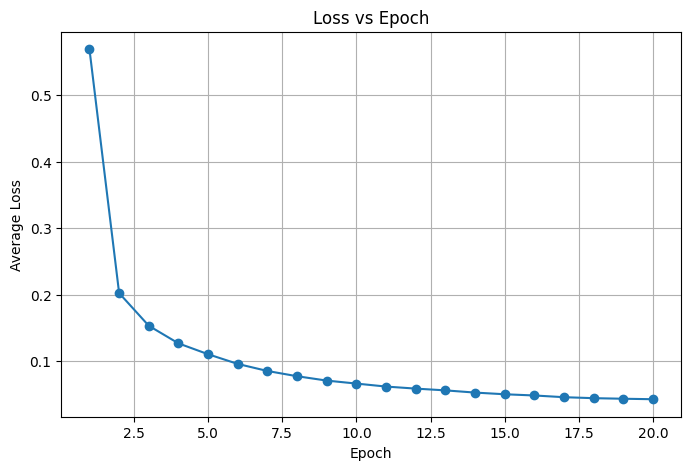

In [36]:
epochs_list = list(range(1, len(avg_loss) + 1))

plt.figure(figsize=(8,5))
plt.plot(epochs_list, avg_loss, marker='o')
plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.grid(True)
plt.show()

CONFUSION MATRIX AND TEST ACCURACY

Test Accuracy: 98.57%


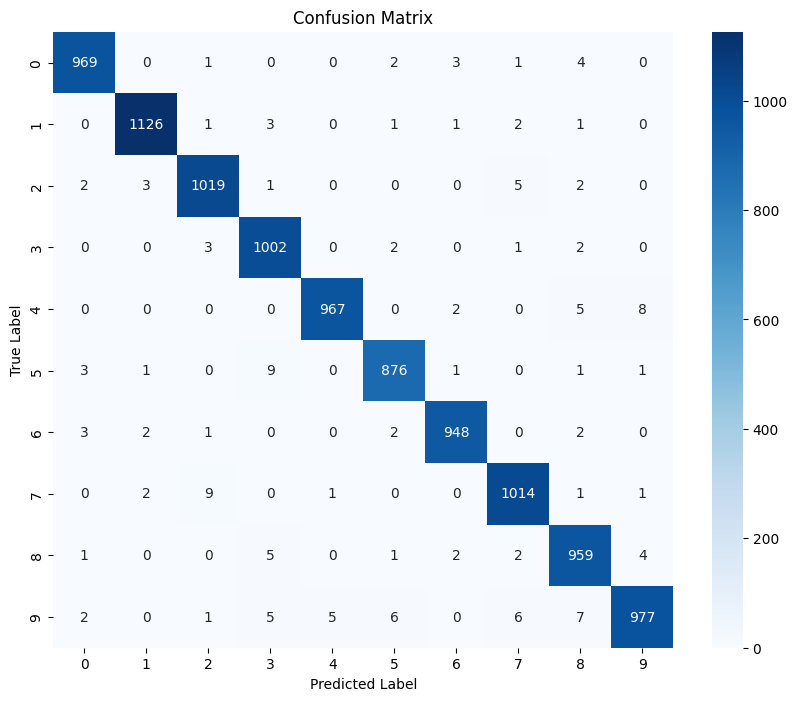

In [37]:
model.eval()
correct = 0
total = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for batch, label in test_loader:
        output = model(batch)
        pred = torch.argmax(output, dim=1)

        correct += (pred == label).sum().item()
        total += label.size(0)

        all_preds.extend(pred.numpy())
        all_labels.extend(label.numpy())


acc = 100 * correct / total
print(f"Test Accuracy: {acc:.2f}%")

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

TRAINABLE PARAMETRES

In [38]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
non_trainable_params = sum(p.numel() for p in model.parameters() if not p.requires_grad)
total_params = trainable_params + non_trainable_params

print(f"Trainable Parameters     : {trainable_params}")
print(f"Non-Trainable Parameters : {non_trainable_params}")
print(f"Total Parameters         : {total_params}")

Trainable Parameters     : 4470
Non-Trainable Parameters : 0
Total Parameters         : 4470


# PART 2 OF ASSIGNMENT 2

# 0 and 6 numbers belong to class 0
Class 0 → {0, 6}
# 1 and 7 numbers belong to class 1
Class 1 → {1, 7}
#2,3,8,5 belong to class 2
Class 2 → {2, 3, 8, 5}
# 4,9 belong to class 3
Class 3 → {4, 9}

In [42]:
transform = transforms.Compose([
    transforms.ToTensor()
])

def map_labels(y):
    if y in [0, 6]:
        return 0
    elif y in [1, 7]:
        return 1
    elif y in [2, 3, 8, 5]:
        return 2
    elif y in [4, 9]:
        return 3

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
    target_transform=map_labels
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
    target_transform=map_labels
)

In [43]:
batch_size = 32
train_loader = DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=batch_size,shuffle=False)
epochs = 20
lr = 0.001
criterion = nn.CrossEntropyLoss()
model = Assignment2(part2 = True)
optimizer = optim.Adam(model.parameters(),lr = lr)

avg_loss = []
for epoch in range(epochs):
  losses = []
  for batch,label in tqdm(train_loader):
    optimizer.zero_grad()
    x = model(batch)

    loss = criterion(x,label)
    losses.append(loss.item())
    loss.backward()
    optimizer.step()
  loss_avg = np.mean(losses)
  avg_loss.append(loss_avg)
  print(f'Epoch {epoch + 1} loss is {loss_avg:.4f}')

100%|██████████| 1875/1875 [00:47<00:00, 39.65it/s]


Epoch 1 loss is 0.2446


100%|██████████| 1875/1875 [00:48<00:00, 38.88it/s]


Epoch 2 loss is 0.0956


100%|██████████| 1875/1875 [00:48<00:00, 38.53it/s]


...

Epoch 18 loss is 0.0201


100%|██████████| 1875/1875 [00:47<00:00, 39.17it/s]


Epoch 19 loss is 0.0188


100%|██████████| 1875/1875 [00:48<00:00, 38.61it/s]

Epoch 20 loss is 0.0182


LOSS VS EPOCHS

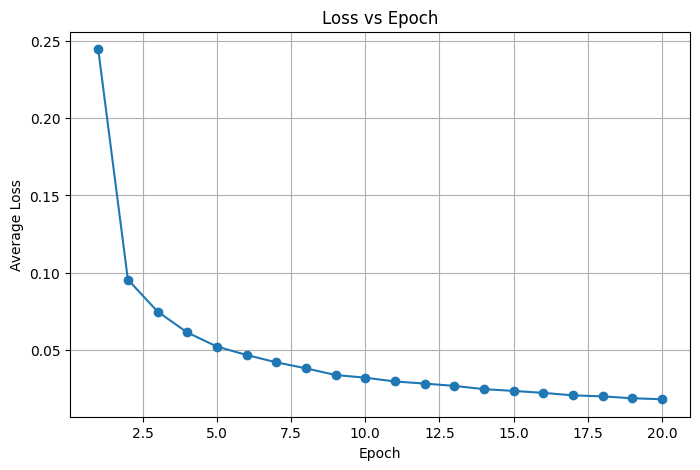

In [44]:
epochs_list = list(range(1, len(avg_loss) + 1))

plt.figure(figsize=(8,5))
plt.plot(epochs_list, avg_loss, marker='o')
plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.grid(True)
plt.show()

ACCURACY AND CONFUSION MATRIX

Test Accuracy: 99.03%


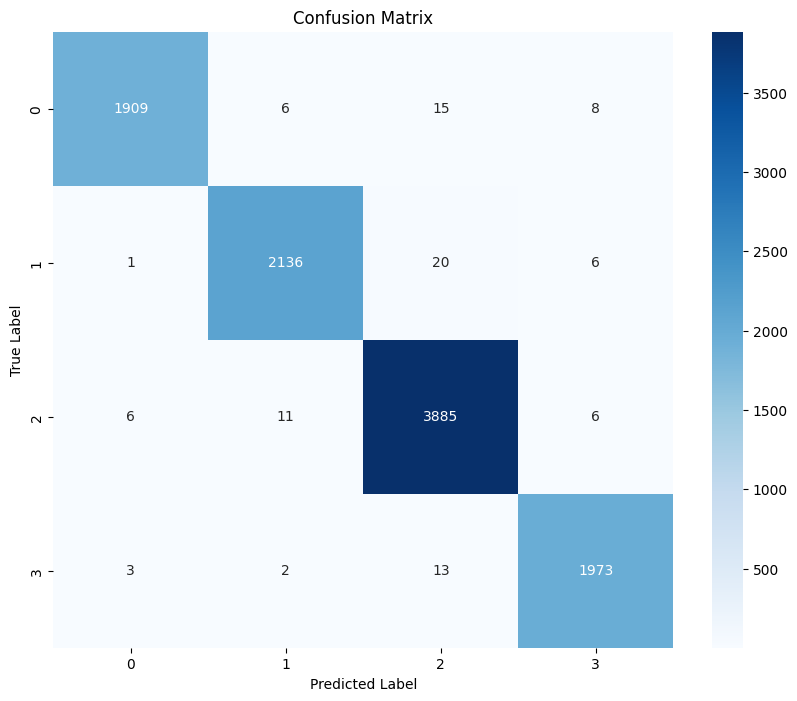

In [45]:
model.eval()
correct = 0
total = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for batch, label in test_loader:
        output = model(batch)
        pred = torch.argmax(output, dim=1)

        correct += (pred == label).sum().item()
        total += label.size(0)

        all_preds.extend(pred.numpy())
        all_labels.extend(label.numpy())


acc = 100 * correct / total
print(f"Test Accuracy: {acc:.2f}%")

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

TRAINABLE PARAMETRES

In [46]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
non_trainable_params = sum(p.numel() for p in model.parameters() if not p.requires_grad)
total_params = trainable_params + non_trainable_params

print(f"Trainable Parameters     : {trainable_params}")
print(f"Non-Trainable Parameters : {non_trainable_params}")
print(f"Total Parameters         : {total_params}")

Trainable Parameters     : 4368
Non-Trainable Parameters : 0
Total Parameters         : 4368
